In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import time

In [2]:
with zipfile.ZipFile('DDOS_Dataset.csv', 'r') as z:
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f)

df['rx_kbps'].fillna(df['rx_kbps'].median(), inplace=True)
df['tot_kbps'].fillna(df['tot_kbps'].median(), inplace=True)

for col in ['src', 'dst', 'Protocol']:
    df[col] = pd.factorize(df[col])[0]

X = df.drop(columns=['label', 'dt']).values
y = df['label'].values

# Convert labels to -1/+1 for gradient boosting
y_gb = np.where(y == 0, -1, 1)

np.random.seed(42)
indices = np.random.permutation(len(X))
split   = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
y_train_gb, y_test_gb = y_gb[train_idx], y_gb[test_idx]

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
std[std == 0] = 1
X_train_sc = (X_train - mean) / std
X_test_sc  = (X_test  - mean) / std

print("Data ready!")
print(f"Train: {X_train_sc.shape}, Test: {X_test_sc.shape}")

Data ready!
Train: (83476, 21), Test: (20869, 21)


/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_86005/2842945379.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rx_kbps'].fillna(df['rx_kbps'].median(), inplace=True)
/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_86005/2842945379.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting v

In [3]:
class DecisionStump:
    """A single-level decision tree — the base learner for boosting"""
    def __init__(self):
        self.feature   = None
        self.threshold = None
        self.left_val  = None
        self.right_val = None

    def fit(self, X, residuals):
        n_samples, n_features = X.shape
        best_loss = float('inf')

        for f in range(n_features):
            col = X[:, f]
            thresholds = np.percentile(col, np.linspace(10, 90, 10))

            for t in thresholds:
                left_mask  = col <= t
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                left_val  = residuals[left_mask].mean()
                right_val = residuals[right_mask].mean()

                loss = (
                    np.sum((residuals[left_mask]  - left_val)  ** 2) +
                    np.sum((residuals[right_mask] - right_val) ** 2)
                )

                if loss < best_loss:
                    best_loss      = loss
                    self.feature   = f
                    self.threshold = t
                    self.left_val  = left_val
                    self.right_val = right_val

    def predict(self, X):
        col  = X[:, self.feature]
        pred = np.where(col <= self.threshold, self.left_val, self.right_val)
        return pred

In [4]:
class GradientBoostingFromScratch:
    def __init__(self, n_estimators=50, learning_rate=0.1):
        self.n_estimators  = n_estimators
        self.learning_rate = learning_rate
        self.trees         = []
        self.f0            = None  # initial prediction

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        # y should be 0/1 labels
        # Initial prediction — log odds
        p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.f0 = np.log(p / (1 - p))
        F = np.full(len(y), self.f0)

        for i in range(self.n_estimators):
            probs     = self._sigmoid(F)
            residuals = y - probs  # negative gradient of log loss

            tree = DecisionStump()
            tree.fit(X, residuals)
            update = tree.predict(X)

            F += self.learning_rate * update
            self.trees.append(tree)

            if (i + 1) % 10 == 0:
                print(f"  Tree {i+1}/{self.n_estimators} done")

    def predict_proba(self, X):
        F = np.full(X.shape[0], self.f0)
        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)
        return self._sigmoid(F)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [5]:
gbt = GradientBoostingFromScratch(n_estimators=50, learning_rate=0.1)

start = time.time()
print("Training Gradient Boosting from scratch...")
gbt.fit(X_train_sc, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred = gbt.predict(X_test_sc)
y_prob = gbt.predict_proba(X_test_sc)

Training Gradient Boosting from scratch...
  Tree 10/50 done
  Tree 20/50 done
  Tree 30/50 done
  Tree 40/50 done
  Tree 50/50 done
Training time: 12.17s


In [6]:
def calc_metrics(y_true, y_pred, y_prob):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    thresholds = np.linspace(0, 1, 100)
    tprs, fprs = [], []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        tp = np.sum((yp == 1) & (y_true == 1))
        fp = np.sum((yp == 1) & (y_true == 0))
        fn = np.sum((yp == 0) & (y_true == 1))
        tn = np.sum((yp == 0) & (y_true == 0))
        tprs.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

    fprs_arr   = np.array(fprs)
    tprs_arr   = np.array(tprs)
    sorted_idx = np.argsort(fprs_arr)
    auc = np.trapz(tprs_arr[sorted_idx], fprs_arr[sorted_idx])

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    return TP, TN, FP, FN, fprs_arr[sorted_idx], tprs_arr[sorted_idx], auc

TP, TN, FP, FN, fprs, tprs, auc = calc_metrics(y_test, y_pred, y_prob)

Accuracy  : 0.8776
Precision : 0.8004
Recall    : 0.9164
F1 Score  : 0.8545
ROC-AUC   : 0.9131


/var/folders/sw/l5gf2q5s2q9d2zrsj3f5d9200000gn/T/ipykernel_86005/3001152622.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tprs_arr[sorted_idx], fprs_arr[sorted_idx])


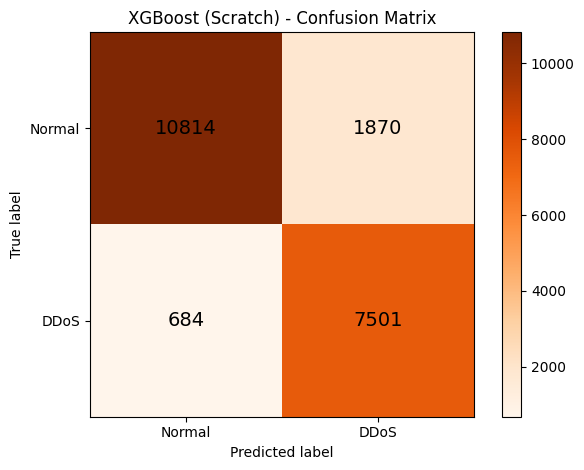

In [7]:
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Oranges')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Normal','DDoS'])
ax.set_yticklabels(['Normal','DDoS'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('XGBoost (Scratch) - Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

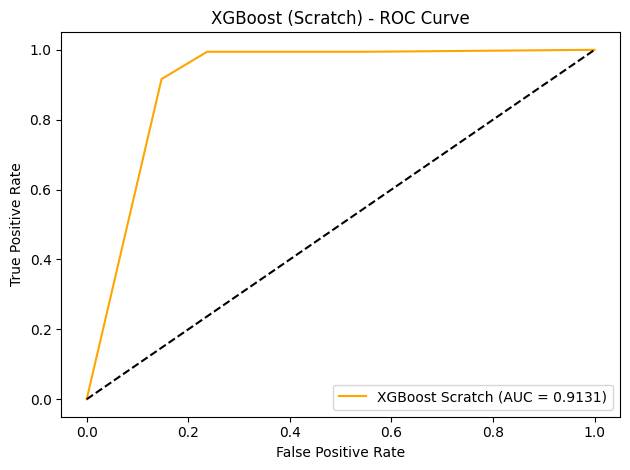

In [8]:
plt.figure()
plt.plot(fprs, tprs, label=f'XGBoost Scratch (AUC = {auc:.4f})', color='orange')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost (Scratch) - ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()